# 05 — Random Forest Model

## Problem
Predict a student's final mathematics grade (**G3**) from the available student information.

A key question in this project is how much previous grades (**G1** and **G2**) help the prediction.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = pd.read_csv("../data/student-mat.csv", sep=";")


## Define the target

**G3** is the final grade, so it is the value we want the model to predict.


In [3]:
y = df["G3"]


## Use the same train/test split for both experiments

Keeping the same split makes the comparison between the two settings fair.


In [4]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42
)

df_train = df.loc[train_idx]
df_test = df.loc[test_idx]

y_train = df_train["G3"]
y_test = df_test["G3"]


## Build the modelling pipeline

The preprocessing is placed inside the pipeline so that it is fitted separately inside each cross-validation split. This avoids using validation-fold information while training.


In [5]:
def make_pipeline(X_train):
    numeric_features = X_train.select_dtypes(include="number").columns
    categorical_features = X_train.select_dtypes(include=["object", "string", "category"]).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ])

    return pipeline


## Model comparison

We will evaluate: 

- **Model A:** without G1 and G2
- **Model B:** with G1 and G2

The same Random Forest search is used for both.


In [6]:
param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [5, 10, 15, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 1.0]
}


In [7]:
def train_model(use_previous_grades):
    drop_cols = ["G3"]
    if not use_previous_grades:
        drop_cols += ["G1", "G2"]

    X = df.drop(columns=drop_cols)
    X_train = X.loc[train_idx]
    X_test = X.loc[test_idx]

    pipeline = make_pipeline(X_train)

    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=30,
        cv=5,
        scoring="r2",
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    predictions = search.predict(X_test)

    return search, predictions


### Model A — Without G1 and G2


In [8]:
model_without_g1g2, pred_without_g1g2 = train_model(use_previous_grades=False)


### Model B — With G1 and G2


In [9]:
model_with_g1g2, pred_with_g1g2 = train_model(use_previous_grades=True)


## Compare the results


In [10]:
def evaluate(y_true, predictions):
    return {
        "MAE": mean_absolute_error(y_true, predictions),
        "MSE": mean_squared_error(y_true, predictions),
        "R²": r2_score(y_true, predictions)
    }

comparison = pd.DataFrame({
    "Without G1/G2": evaluate(y_test, pred_without_g1g2),
    "With G1/G2": evaluate(y_test, pred_with_g1g2)
})

comparison


,Without G1/G2,With G1/G2
MAE,2.997053,1.211785
MSE,14.150586,4.115576
R²,0.309897,0.799290


### Interpretation

The comparison shows how strongly previous grades affect predictability. The **without-G1/G2** setting is a harder and more realistic test of whether other student information can predict the final grade.


## Focus on the model without G1 and G2

This is the more challenging version, so we inspect its predictions and errors rather than hiding its weaknesses.


In [11]:
y_pred = pred_without_g1g2
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})
results["Absolute Error"] = (results["Actual"] - results["Predicted"]).abs()

results.sort_values("Absolute Error", ascending=False).head(10)


,Actual,Predicted,Absolute Error
140,0,10.446178,10.446178
316,0,10.097008,10.097008
168,0,8.429959,8.429959
113,19,11.533840,7.466160
334,0,7.299454,7.299454
182,17,10.133109,6.866891
324,15,8.283798,6.716202
177,6,11.844001,5.844001
209,7,12.657480,5.657480
82,6,11.576368,5.576368


## Actual vs predicted


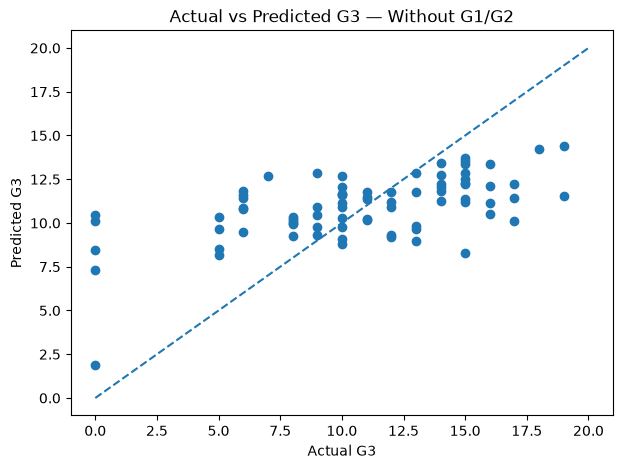

In [12]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred)
plt.plot([0, 20], [0, 20], linestyle="--")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted G3 — Without G1/G2")
plt.show()


## Prediction errors


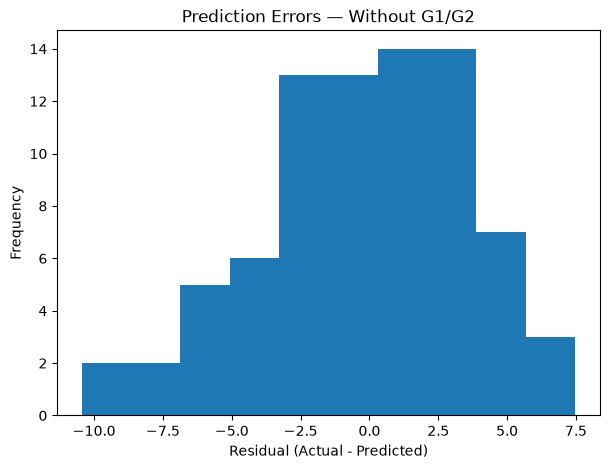

In [13]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=10)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Prediction Errors — Without G1/G2")
plt.show()


## Feature importance


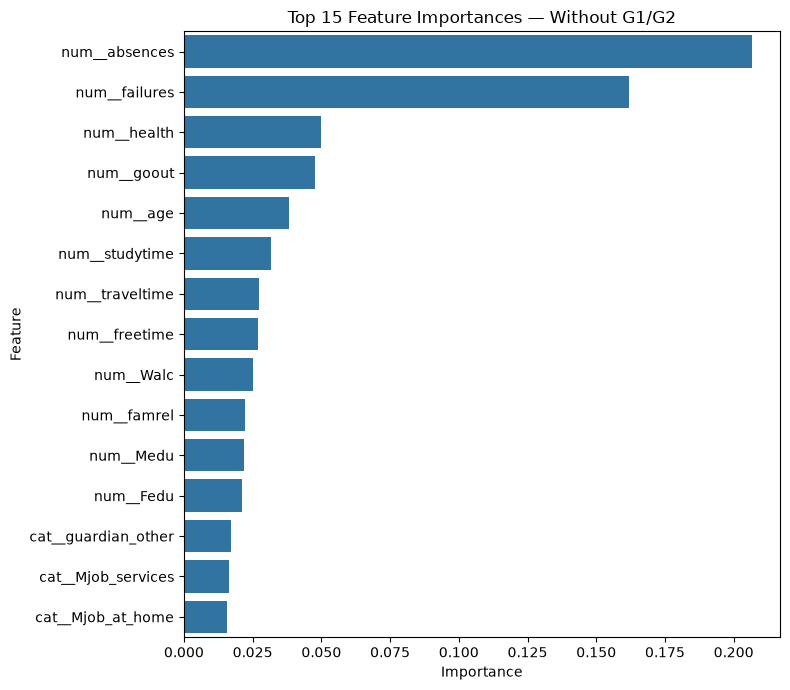

In [14]:
best_pipeline = model_without_g1g2.best_estimator_
preprocessor = best_pipeline.named_steps["preprocessor"]
rf = best_pipeline.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(rf.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 7))
sns.barplot(x=importances.values, y=importances.index)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Without G1/G2")
plt.tight_layout()
plt.show()


## Conclusion

The Random Forest can learn useful patterns from the available student information, but predictions become less reliable for unusual or extreme final grades when G1 and G2 are excluded.

The comparison also shows why previous grades are powerful predictors: they contain information that is much closer to the final outcome.

A limitation of this project is the relatively small dataset (**395 students**), so some uncommon cases are difficult for the model to learn well. The model should therefore be viewed as a prediction experiment, not as a system that can perfectly predict an individual student's final grade.
